In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf


# Load data

In [3]:
df = pd.read_csv('auto-mpg.csv', index_col=0)

In [4]:
df.columns[0]

'mpg'

In [5]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [6]:
df[(df["mpg"]>=20) & (df["acceleration"]< 15) & (df["origin"]==2)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
21,24.0,4,107.0,90,2430,14.5,70,2,audi 100 ls
23,26.0,4,121.0,113,2234,12.5,70,2,bmw 2002
50,28.0,4,116.0,90,2123,14.0,71,2,opel 1900
52,30.0,4,88.0,76,2065,14.5,71,2,fiat 124b
119,20.0,4,114.0,91,2582,14.0,73,2,audi 100ls
122,24.0,4,121.0,110,2660,14.0,73,2,saab 99le
143,26.0,4,97.0,78,2300,14.5,74,2,opel manta
148,26.0,4,116.0,75,2246,14.0,74,2,fiat 124 tc
175,29.0,4,90.0,70,1937,14.0,75,2,volkswagen rabbit
179,22.0,4,121.0,98,2945,14.5,75,2,volvo 244dl


In [7]:
# fix column names by replacing spaces with underscores
df.columns = df.columns.str.replace(' ', '_')

In [8]:
df.horsepower.value_counts(sort="alphabet")
# ? included in numeric column -> must be imputed

horsepower
150    22
90     20
88     19
110    18
100    17
       ..
61      1
93      1
148     1
152     1
82      1
Name: count, Length: 94, dtype: int64

In [9]:
# Impute data for EDA
# Make data copy
df_eda = df.copy()
df_eda.horsepower = pd.to_numeric(df_eda.horsepower, errors="coerce")

In [10]:
df_eda.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [11]:
df_eda.drop("car_name", axis=1, inplace=True)

In [12]:
df_eda.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin            int64
dtype: object

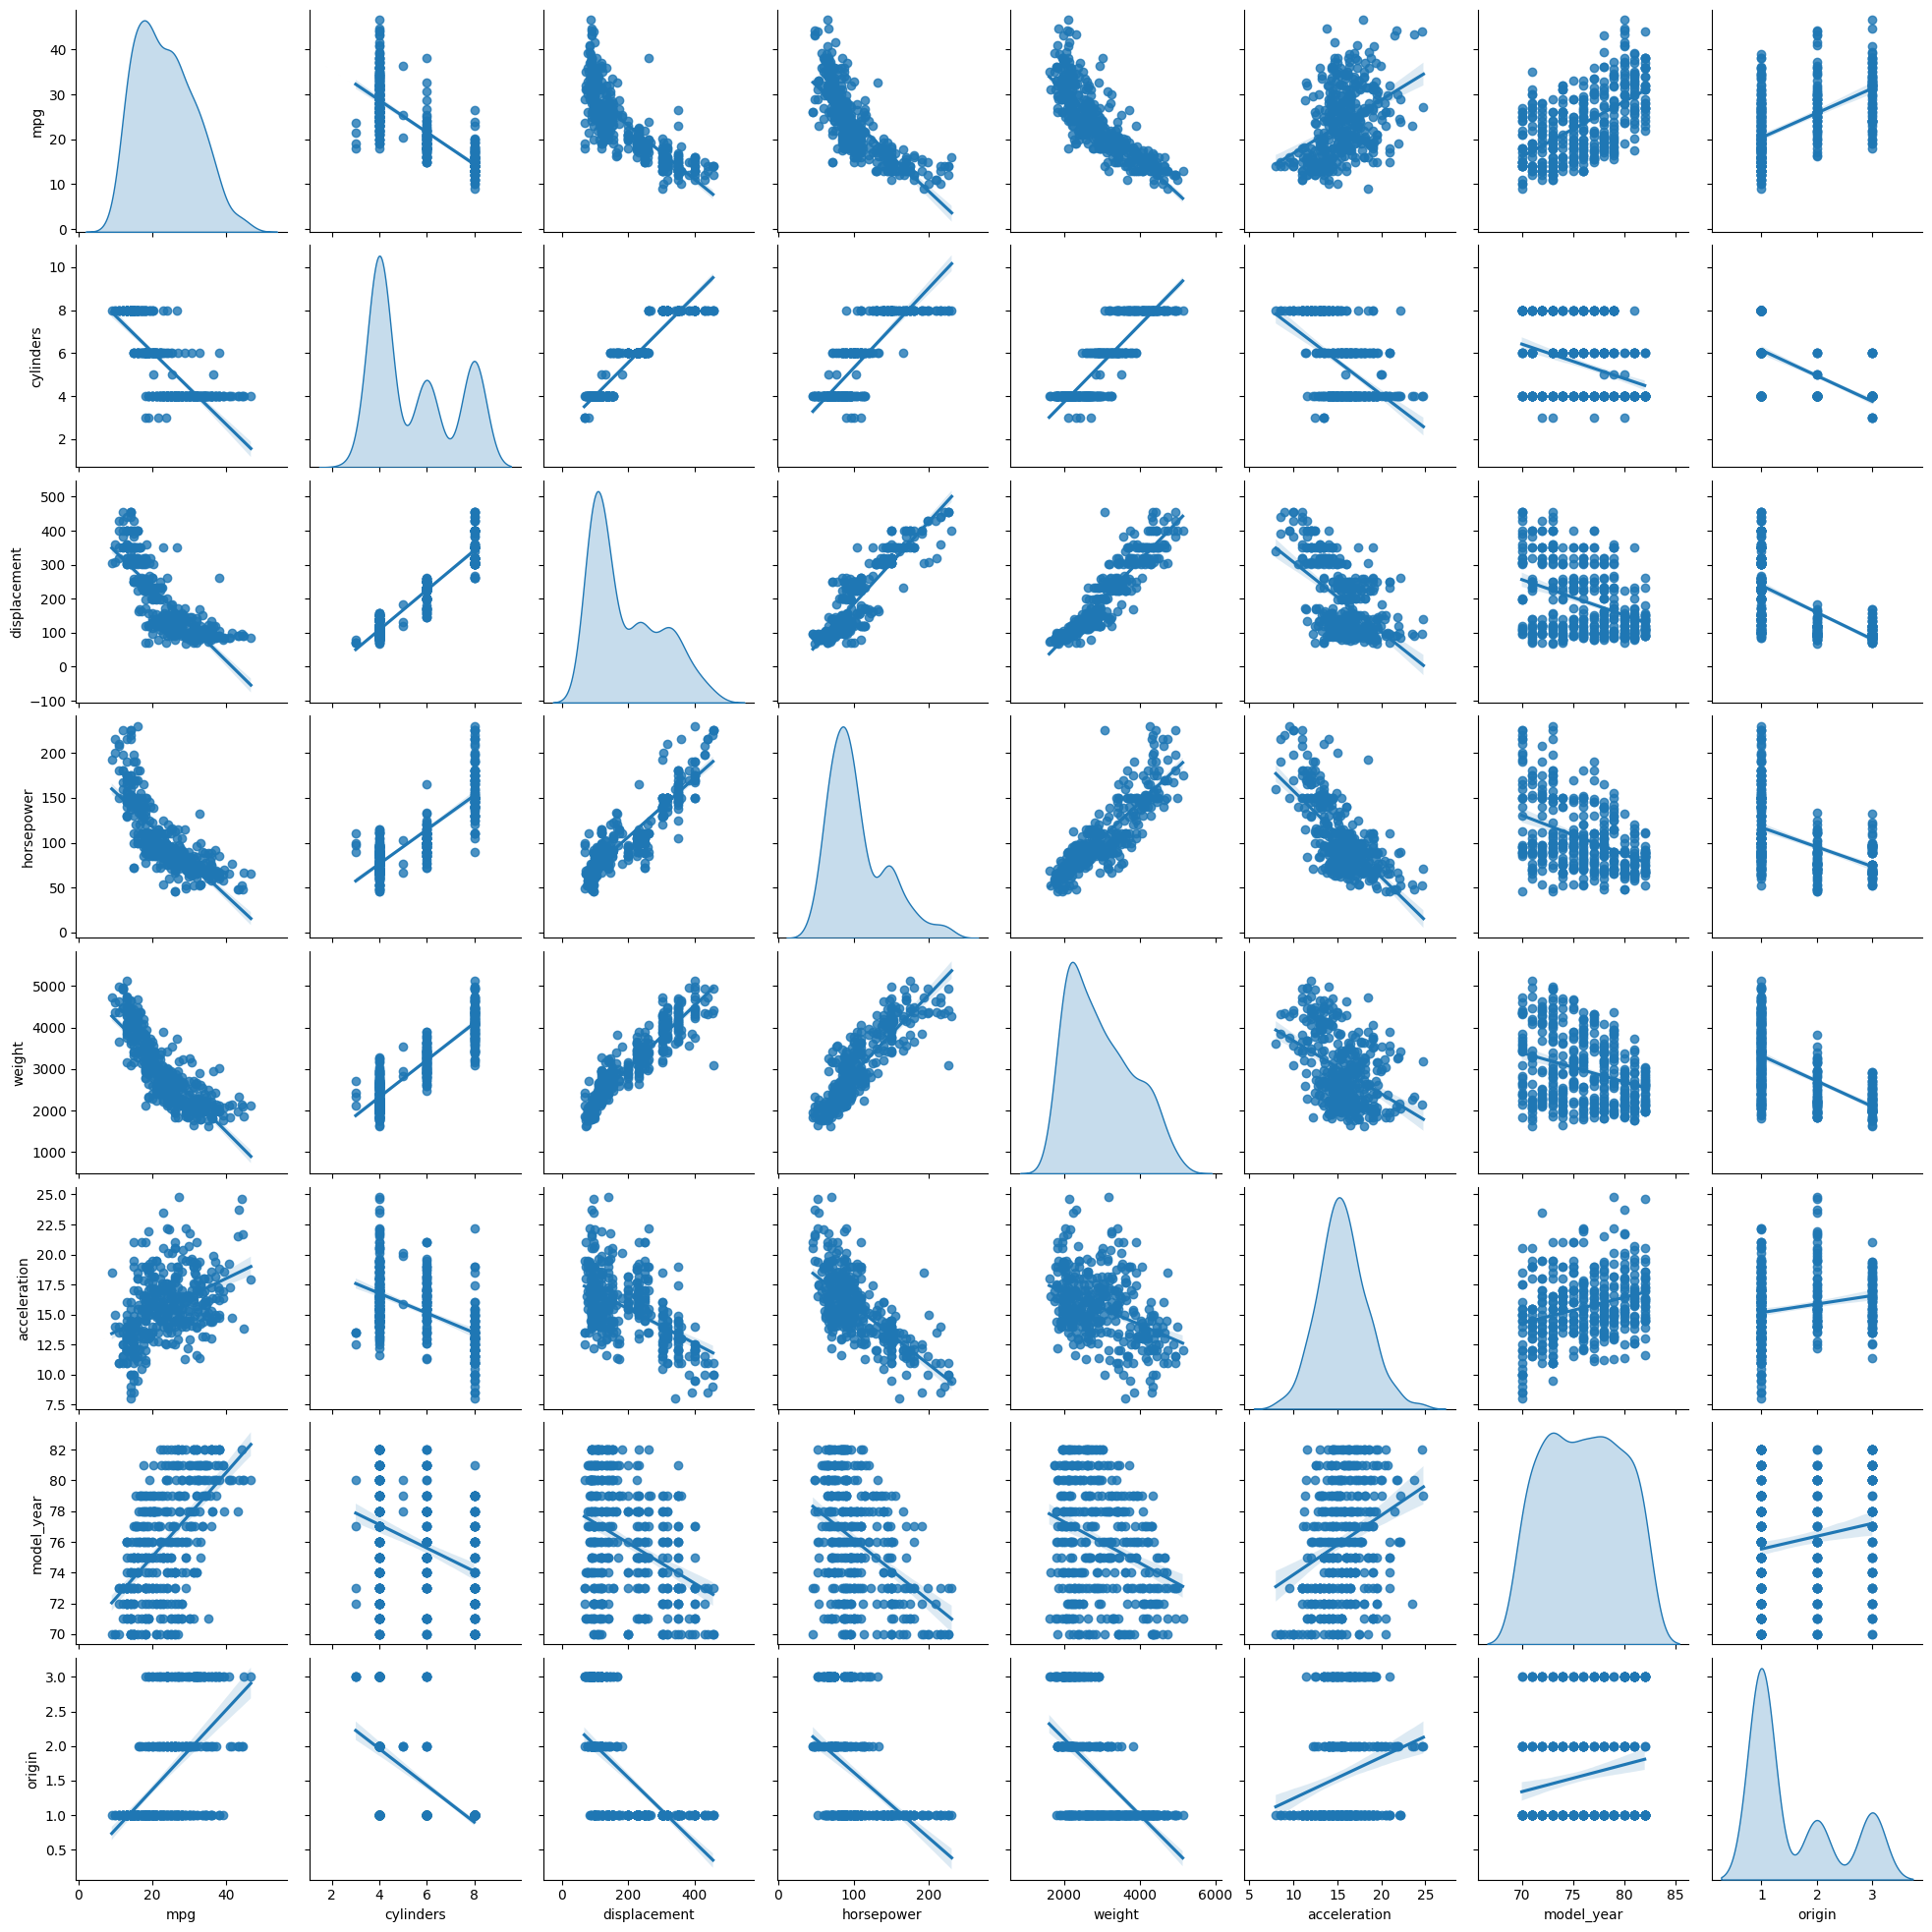

In [13]:
# Brief EDA visualization
sns.pairplot(df_eda, diag_kind="kde", kind="reg")

<Axes: >

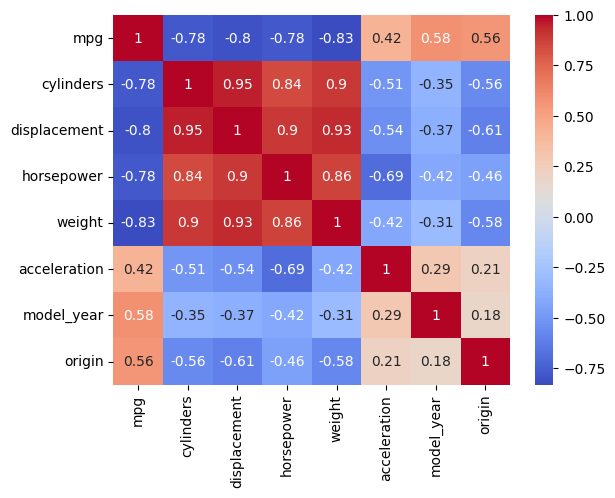

In [14]:
sns.heatmap(df_eda.select_dtypes("number").corr(), cmap="coolwarm", annot=True)

In [15]:
# High correlation between cylinders, displacement, horsepower, weight
# Run analysis for the time being, regularize, PCA at the end

In [16]:
df_eda = pd.concat([df_eda, np.log(df_eda["mpg"]).rename("log_mpg")], axis=1)

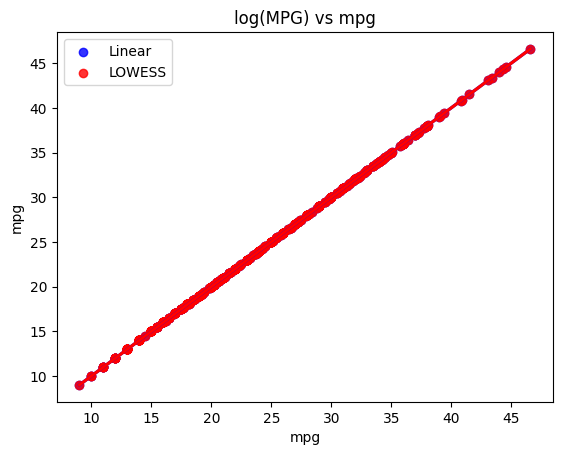

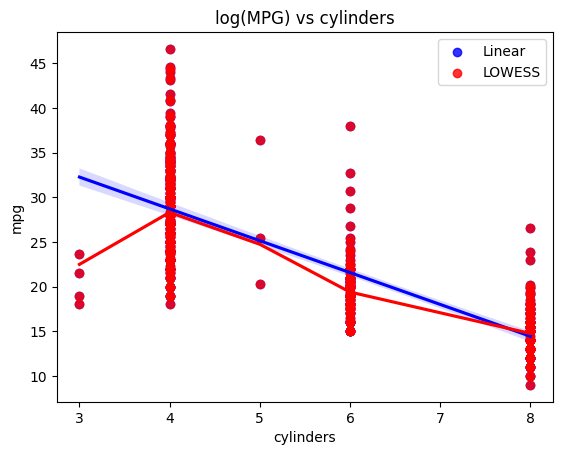

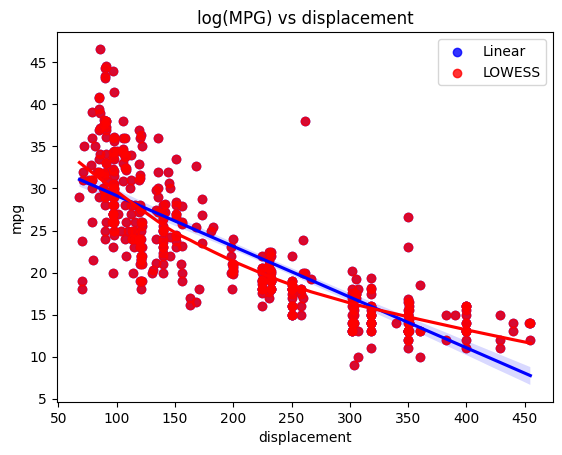

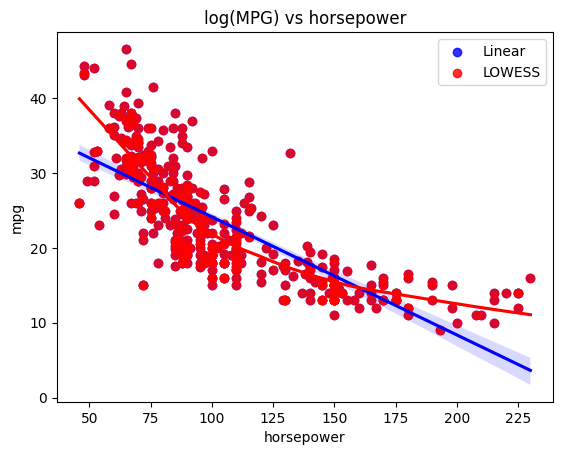

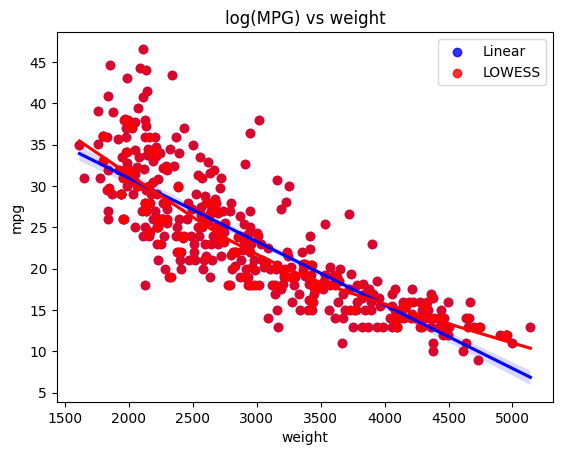

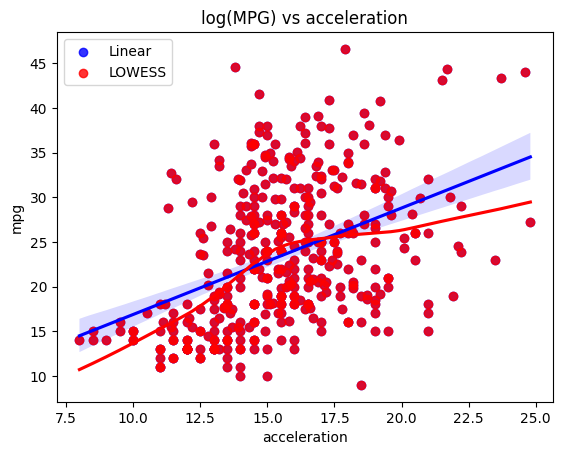

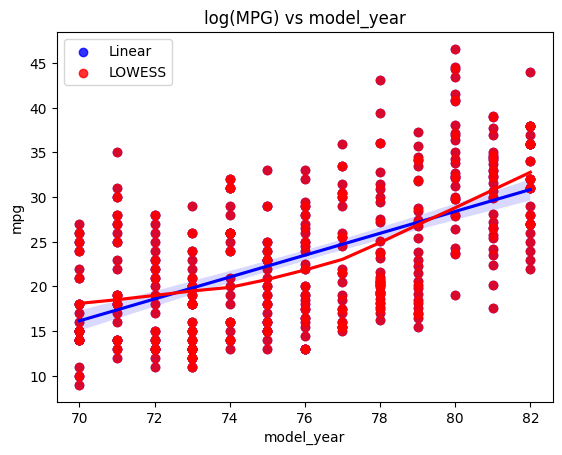

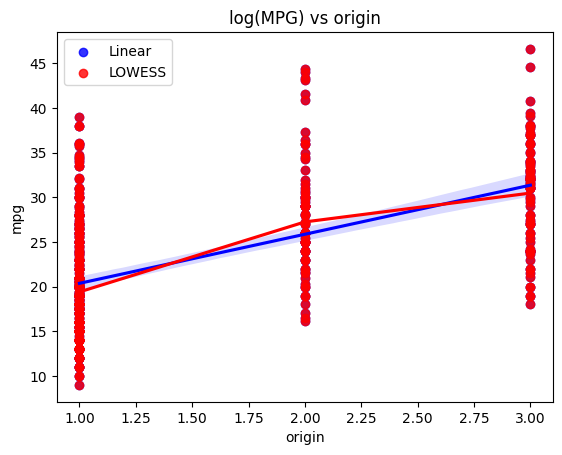

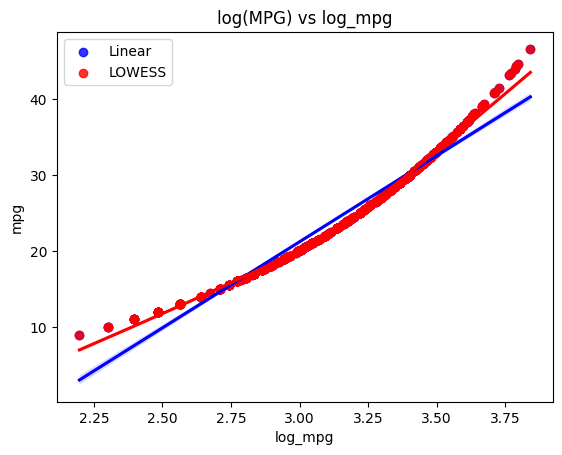

In [17]:
# Regression plots for each numerical feature with both lowess and linear regression estimate
import matplotlib.pyplot as plt
import seaborn as sns

for feature in df_eda.select_dtypes("number").columns:
    # Linear regression line
    sns.regplot(x=feature, y="mpg", data=df_eda, scatter=True, label="Linear", color="blue")
    # LOWESS line
    sns.regplot(x=feature, y="mpg", data=df_eda, lowess=True, label="LOWESS", color="red")
    # Scatter plot (optional)
    #sns.scatterplot(x=feature, y="mpg", data=df_eda, alpha=0.5, color="gray")
    plt.title(f"log(MPG) vs {feature}")
    plt.legend()
    plt.show()

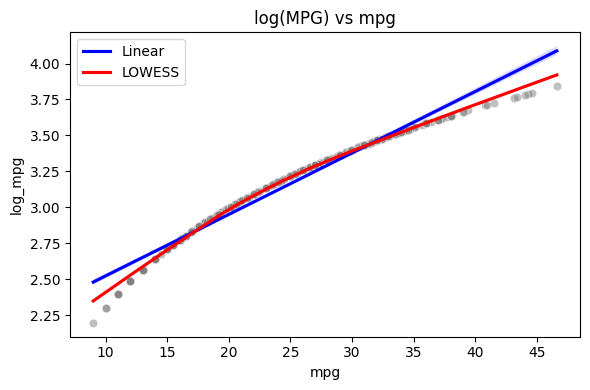

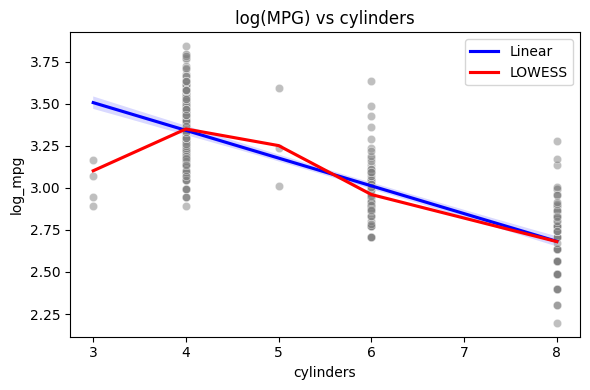

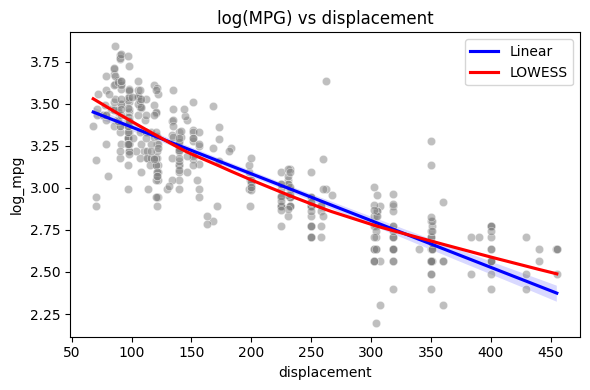

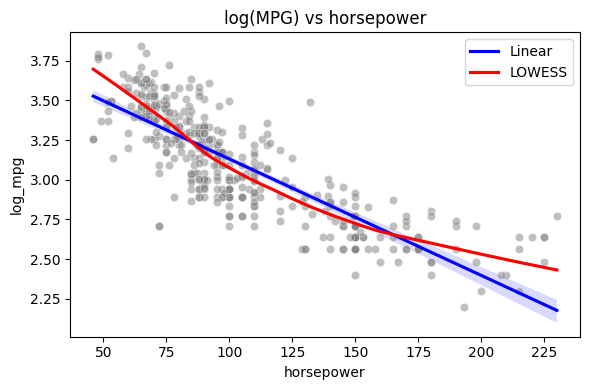

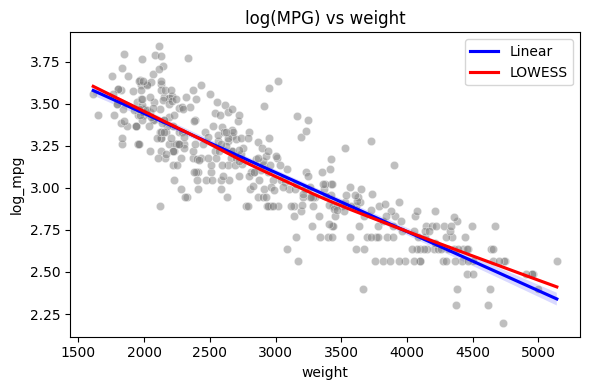

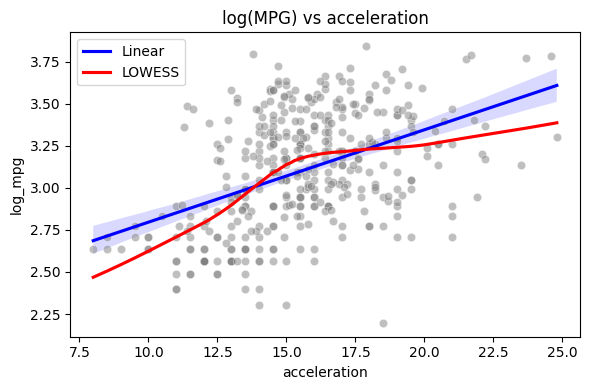

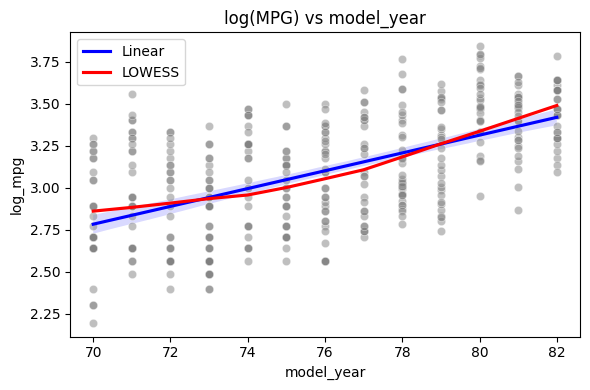

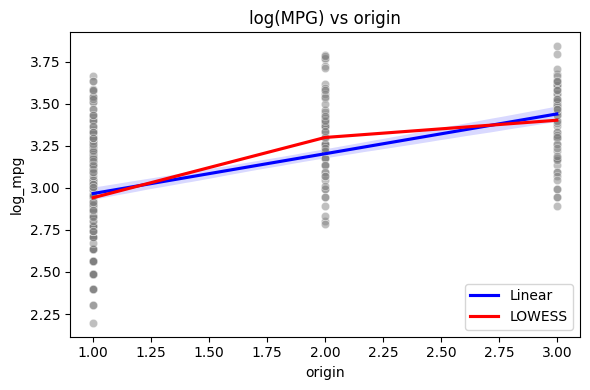

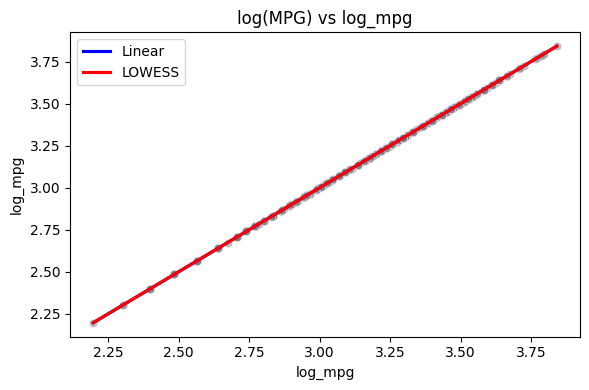

In [18]:
# Regression plots for each numerical feature with both lowess and linear regression estimate
import matplotlib.pyplot as plt
import seaborn as sns

for feature in df_eda.select_dtypes("number").columns:
    plt.figure(figsize=(6, 4))

    # Linear regression line
    sns.regplot(x=feature, y="log_mpg", data=df_eda, scatter=False, label="Linear", color="blue")

    # LOWESS line
    sns.regplot(x=feature, y="log_mpg", data=df_eda, scatter=False, lowess=True, label="LOWESS", color="red")

    # Scatter plot (optional)
    sns.scatterplot(x=feature, y="log_mpg", data=df_eda, alpha=0.5, color="gray")

    plt.title(f"log(MPG) vs {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()

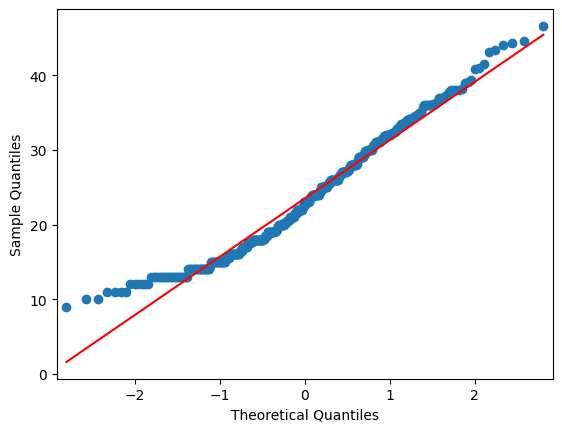

In [19]:
plot = sm.qqplot(df.mpg, line="s")

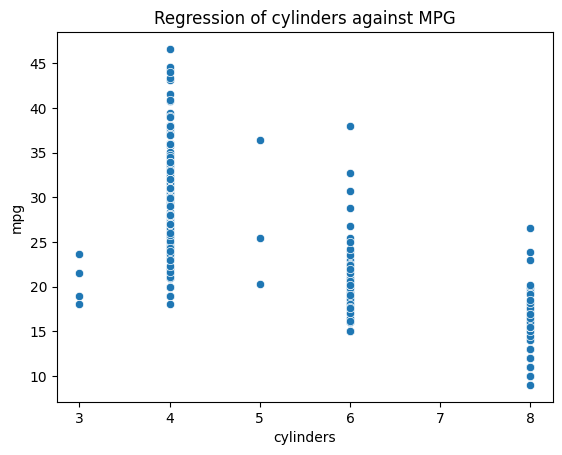

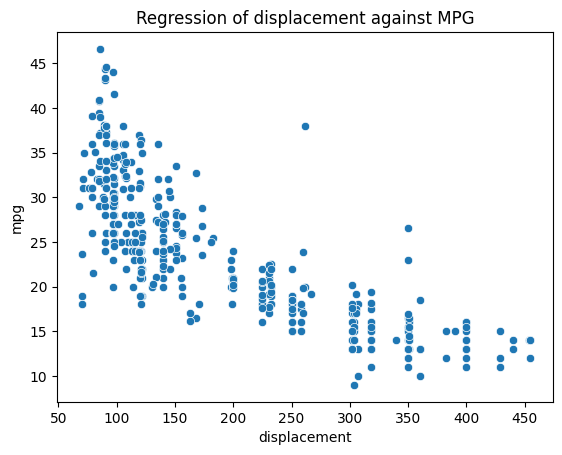

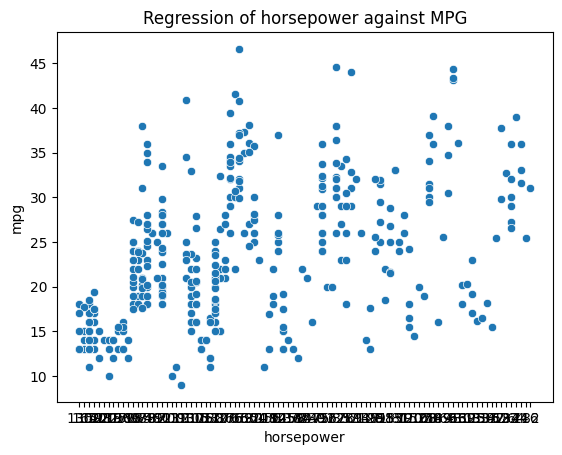

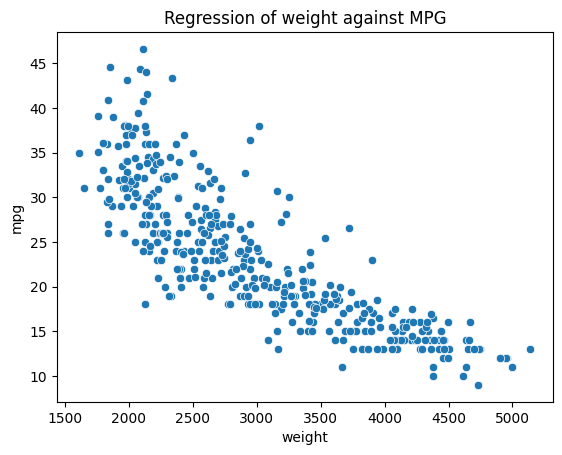

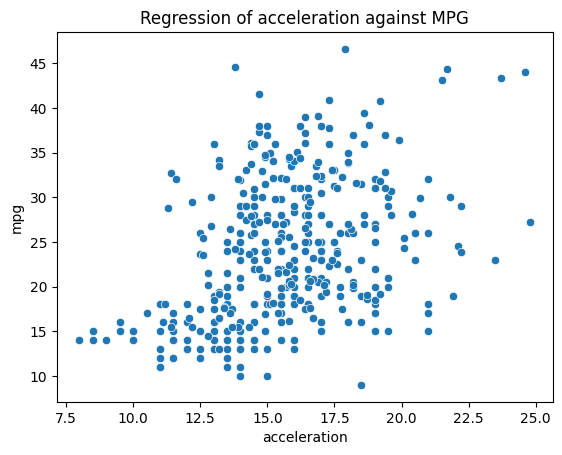

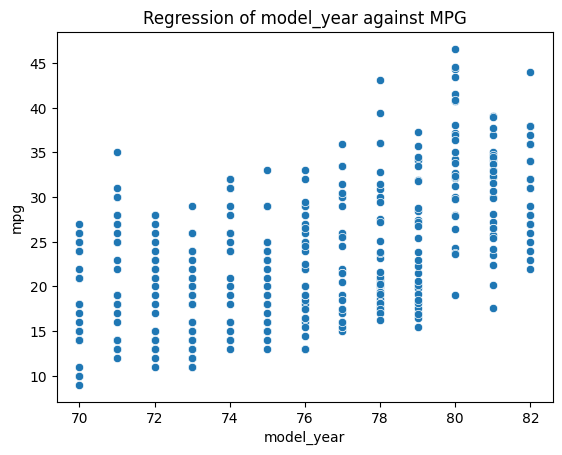

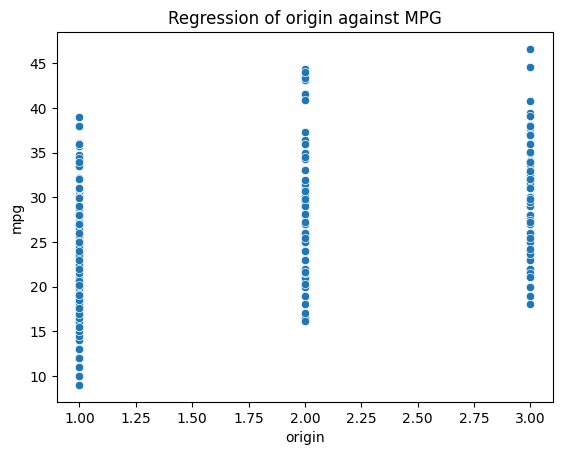

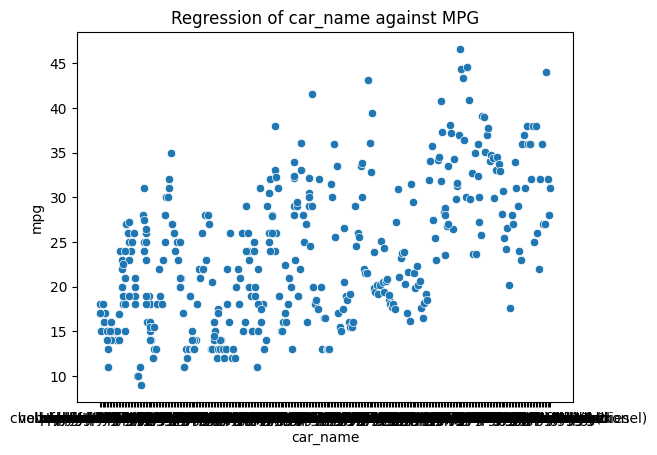

In [20]:
for col in df.drop("mpg", axis = 1):
    sns.scatterplot(x=df[col], y=df["mpg"])
    plt.title(f"Regression of {col} against MPG")
    plt.show()

# Feature generation

In [21]:
# Create  column from first word of car name
df["make"] = df["car_name"].str.split(" ", n=1).str[0]
df["make"] = df.make.astype("object")
df.drop("car_name", axis=1, inplace=True)
df.origin = df["origin"].astype("object")
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model_year        int64
origin           object
make             object
dtype: object

In [22]:
df["make"].replace(
    to_replace=["chevrolet", "buick", "dodge", "ford", "pontiac", "maxda", "vokswagen", "volkswagen", "mercedes-benz", "toyouta", "chevroelt"],
    value=["chevy", "buick", "dodge", "ford", "pontiac", "mazda", "vw", "vw", "mercedes", "toyota", "chevy"],
    inplace=True,
)
df["make"].value_counts()

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_33199/1347139780.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["make"].replace(


make
ford          51
chevy         47
plymouth      31
amc           28
dodge         28
toyota        26
datsun        23
vw            22
buick         17
pontiac       16
honda         13
mazda         12
mercury       11
oldsmobile    10
fiat           8
peugeot        8
audi           7
volvo          6
chrysler       6
renault        5
saab           4
opel           4
subaru         4
mercedes       3
cadillac       2
bmw            2
capri          1
hi             1
triumph        1
nissan         1
Name: count, dtype: int64

In [23]:
# Segment data into train and test
from sklearn.model_selection import train_test_split

df.horsepower = pd.to_numeric(df.horsepower, errors="coerce")
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Impute median
df_train["horsepower"] = df_train.horsepower.fillna(df_train.horsepower.median())
df_test["horsepower"] = df_test.horsepower.fillna(df_train.horsepower.median())

X_train, X_test, y_train, y_test =  train_test_split(
    df_train.drop("mpg", axis=1),
    df_train["mpg"],
    test_size=0.2,
    random_state=42,
)

# Apply standardscaler to numeric columns only and retain column names
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [24]:
X_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,make
61,-0.854207,-0.686044,-0.459454,-0.896917,0.260351,-1.153161,1,ford
103,1.510573,2.016416,1.276286,2.382294,-0.622783,-0.872603,1,chevy
302,-0.854207,-0.851303,-0.893389,-0.986856,-0.304855,0.810747,1,plymouth
338,-0.854207,-0.559670,-0.513696,-0.584499,-0.022252,1.371864,1,plymouth
397,-0.854207,-0.715208,-0.567938,-0.312316,1.284786,1.652422,1,chevy
...,...,...,...,...,...,...,...,...
95,1.510573,2.551076,3.310356,2.327857,-1.682543,-0.872603,1,buick
287,1.510573,1.540083,0.950834,1.149187,-0.905386,0.810747,1,mercury
316,0.328183,0.315227,-0.350971,0.469914,1.037508,1.091306,1,dodge
273,-0.854207,-0.715208,-0.161124,-0.685088,-0.304855,0.530189,3,datsun


# Initial model fit

In [25]:
# Build simple OLS model
OLS = smf.ols(formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + model_year + C(origin)", data=pd.concat([X_train, y_train], axis=1))
OLSresults = OLS.fit()
print(OLSresults.summary())
OLSpreds = OLSresults.predict(X_test)
# Evaluate model
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, OLSpreds)
r2 = r2_score(y_test, OLSpreds)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     138.2
Date:                Fri, 25 Jul 2025   Prob (F-statistic):           2.74e-86
Time:                        14:16:18   Log-Likelihood:                -665.52
No. Observations:                 254   AIC:                             1349.
Df Residuals:                     245   BIC:                             1381.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         22.5215      0.313     72.

In [26]:
# Build regularized OLS model
OLS_reg = smf.ols(formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + model_year + C(origin)", data=pd.concat([X_train, y_train], axis=1))
OLS_reg_results = OLS_reg.fit_regularized(alpha=0.2, L1_wt=1, refit=True)
print(OLS_reg_results.summary())
OLS_regpreds = OLS_reg_results.predict(X_test)
# Evaluate regularized model
mse_reg = mean_squared_error(y_test, OLS_regpreds)
r2_reg = r2_score(y_test, OLS_regpreds)
print(f"Regularized Mean Squared Error: {mse_reg}")
print(f"Regularized R^2 Score: {r2_reg}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     256.6
Date:                Fri, 25 Jul 2025   Prob (F-statistic):           3.19e-87
Time:                        14:16:18   Log-Likelihood:                -675.25
No. Observations:                 254   AIC:                             1361.
Df Residuals:                     250   BIC:                             1378.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         23.4921      0.218    107.

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1952: RuntimeWarning: divide by zero encountered in matmul
  eigvals = np.linalg.eigvalsh(wx.T @ wx)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1952: RuntimeWarning: overflow encountered in matmul
  eigvals = np.linalg.eigvalsh(wx.T @ wx)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1952: RuntimeWarning: invalid value encountered in matmul
  eigvals = np.linalg.eigvalsh(wx.T @ wx)


In [27]:
# Model is incorrectly specified; non-normal, high condition number

In [28]:
# Fit Gamma GLM
Gamma = smf.glm(formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + model_year + C(origin)",
                data=pd.concat([X_train, y_train], axis=1),
                family=sm.families.Gamma(link=sm.families.links.Log()))
Gamma_results = Gamma.fit()
print(Gamma_results.summary())
Gamma_preds = Gamma_results.predict(X_test)
# Evaluate Gamma model
mse_gamma = mean_squared_error(y_test, Gamma_preds)
r2_gamma = r2_score(y_test, Gamma_preds)
print(f"Gamma Mean Squared Error: {mse_gamma}")
print(f"Gamma R^2 Score: {r2_gamma}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    mpg   No. Observations:                  254
Model:                            GLM   Df Residuals:                      245
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                        0.014004
Method:                          IRLS   Log-Likelihood:                -602.79
Date:                Fri, 25 Jul 2025   Deviance:                       3.4605
Time:                        14:16:18   Pearson chi2:                     3.43
No. Iterations:                    10   Pseudo R-squ. (CS):             0.9991
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.0759      0.011    281.

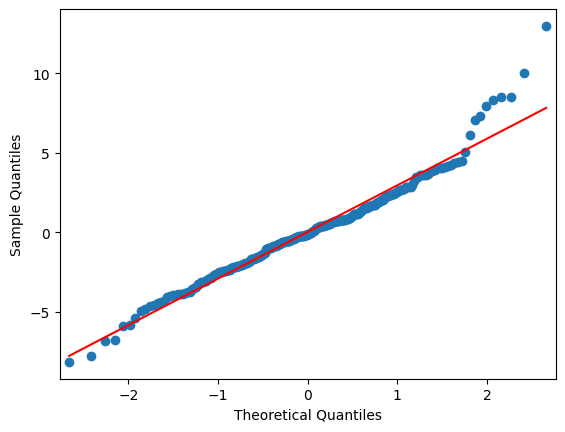

In [29]:
# Check normality of residuals
plot = sm.qqplot(Gamma_results.resid_response, line="s")

# Combatting multicollinearity

In [30]:
# Deal with multicollinearity through PCA of Horsepower, weight, displacement, cylinders
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca_val = pca.fit_transform(X_train[["horsepower", "weight", "displacement", "cylinders"]])
X_test_pca_val = pca.transform(X_test[["horsepower", "weight", "displacement", "cylinders"]])
# Append PCA to X_train and X_test
X_train_pca_df = pd.DataFrame(X_train_pca_val, columns=["PC1", "PC2"], index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca_val, columns=["PC1", "PC2"], index=X_test.index)
# Concatenate PCA components with original data
X_train_pca = pd.concat([X_train, X_train_pca_df], axis=1)
X_test_pca = pd.concat([X_test, X_test_pca_df], axis=1)
# Drop original columns
X_train_pca = X_train_pca.drop(["horsepower", "weight", "displacement", "cylinders"], axis=1)
X_test_pca = X_test_pca.drop(["horsepower", "weight", "displacement", "cylinders"], axis=1)

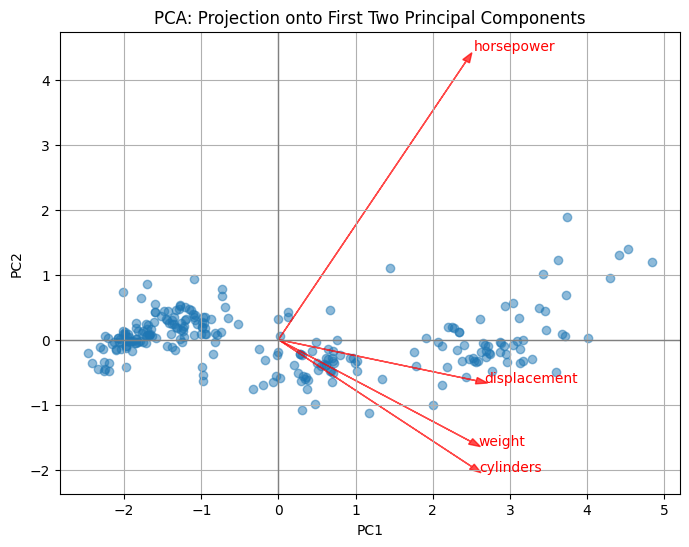

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Get PCA components and explained variance
components = pca.components_
explained_variance = pca.explained_variance_ratio_

# Feature names
features = ["horsepower", "weight", "displacement", "cylinders"]

# Scatter plot of the PCA-transformed training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca_df["PC1"], X_train_pca_df["PC2"], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Projection onto First Two Principal Components")

# Add vectors for each original feature
for i, feature in enumerate(features):
    plt.arrow(0, 0, 
              components[0, i]*5, components[1, i]*5, 
              color='r', alpha=0.7, head_width=0.1)
    plt.text(components[0, i]*5.2, components[1, i]*5.2, feature, color='r')

plt.grid(True)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.show()

<Axes: >

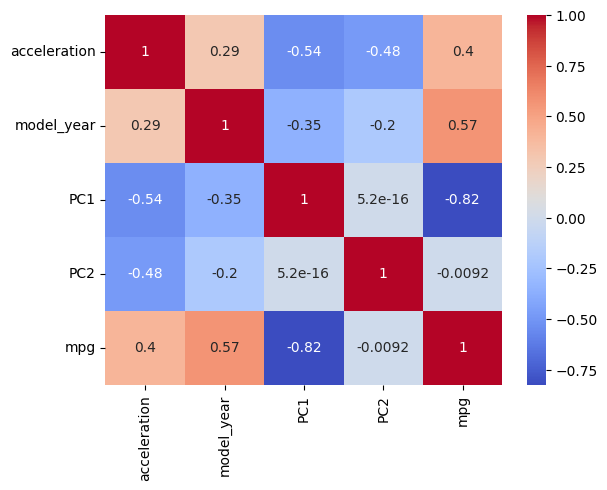

In [32]:
sns.heatmap(pd.concat([X_train_pca.select_dtypes("number"), y_train], axis=1).corr(), cmap="coolwarm", annot=True)

In [33]:
# Improved model fit

In [34]:
# Refit OLS
OLS_pca = smf.ols(formula = "mpg ~ PC1 + PC2 + acceleration + model_year + C(origin)",
                data=pd.concat([X_train_pca, y_train], axis=1))
OLS_pca_results = OLS_pca.fit()
print(OLS_pca_results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     148.0
Date:                Fri, 25 Jul 2025   Prob (F-statistic):           7.82e-79
Time:                        14:16:18   Log-Likelihood:                -688.63
No. Observations:                 254   AIC:                             1391.
Df Residuals:                     247   BIC:                             1416.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         22.7787      0.330     69.

In [67]:
# Refit Gamma
from flask.cli import F
from sklearn.metrics import mean_absolute_error


Gamma_pca = smf.glm(formula = "mpg ~ PC1 + PC2 + acceleration + model_year + C(origin)",
                    data=pd.concat([X_train_pca, y_train], axis=1),
                    family=sm.families.Gamma(link=sm.families.links.Log()))
Gamma_pca_results = Gamma_pca.fit(cov_type='HC3')
print(Gamma_pca_results.summary())
Gamma_pca_preds = Gamma_pca_results.predict(X_test_pca)
# Evaluate PCA Gamma model
mse_gamma_pca = mean_squared_error(y_test, Gamma_pca_preds)
mae_gamma_pca = mean_absolute_error(y_test, Gamma_pca_preds)
r2_gamma_pca = r2_score(y_test, Gamma_pca_preds)
print(f"PCA Gamma Mean Squared Error: {mse_gamma_pca}")
print(f"PCA Gamma Mean Absolute Error: {mae_gamma_pca}")
print(f"PCA Gamma R^2 Score: {r2_gamma_pca}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    mpg   No. Observations:                  254
Model:                            GLM   Df Residuals:                      247
Model Family:                   Gamma   Df Model:                            6
Link Function:                    Log   Scale:                        0.017560
Method:                          IRLS   Log-Likelihood:                -628.99
Date:                Fri, 25 Jul 2025   Deviance:                       4.2476
Time:                        14:23:52   Pearson chi2:                     4.34
No. Iterations:                    11   Pseudo R-squ. (CS):             0.9955
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.0865      0.009    325.

In [36]:
from scipy import stats # For zscore and gamma distribution
Gamma_std_deviance_residuals = stats.zscore(Gamma_pca_results.resid_deviance)


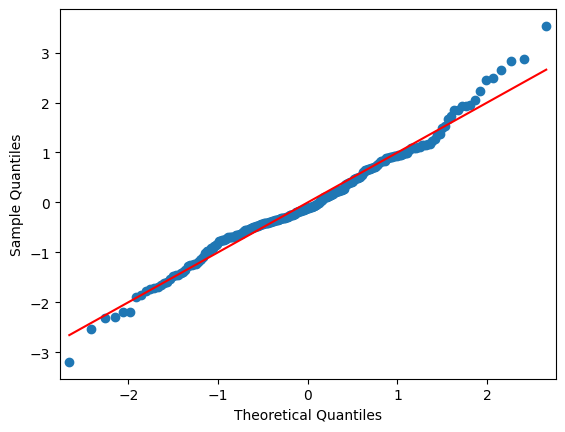

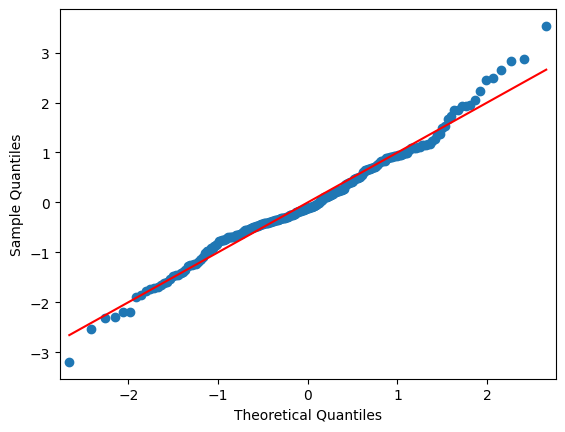

In [37]:
sm.qqplot(Gamma_std_deviance_residuals, line="s")

<Axes: xlabel='None', ylabel='None'>

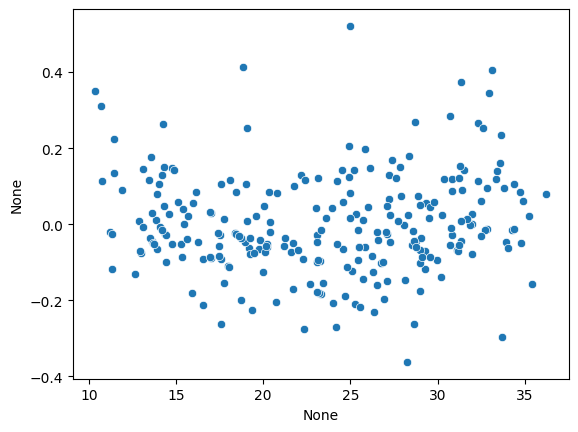

In [38]:
sns.scatterplot(x=Gamma_pca_results.fittedvalues, y=Gamma_pca_results.resid_pearson)

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


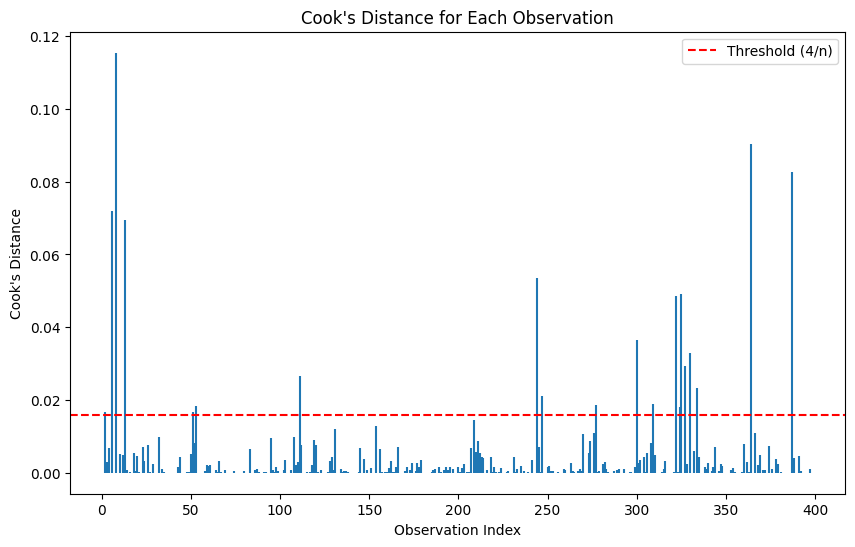

In [54]:
Gamma_pca_influence = Gamma_pca_results.get_influence().summary_frame()

# Plot cook's distance
plt.figure(figsize=(10, 6))
plt.stem(Gamma_pca_influence.index, Gamma_pca_influence["cooks_d"], markerfmt=" ", basefmt=" ")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Each Observation")
plt.axhline(y=4/len(Gamma_pca_influence), color='r', linestyle='--', label='Threshold (4/n)')
plt.legend()
plt.show()

In [40]:
cooks_threshold = 4 / len(Gamma_pca_influence)
cooks_threshold

0.015748031496062992

In [ ]:
Gamma_pca_influence = Gamma_pca_results.get_influence().summary_frame()

# Retrieve from X_train the most influential observations based on Cook's distance
influential_indices = Gamma_pca_influence.sort_values("cooks_d", ascending=False).head(10).index
influential_observations = X_train_pca.loc[influential_indices]

8      0.115432
364    0.090303
387    0.082703
6      0.071804
13     0.069360
244    0.053567
325    0.049140
322    0.048471
300    0.036411
330    0.032999
Name: cooks_d, dtype: float64

In [42]:
# Retrieve the rows from X_train corresponding to these indices
influential_indices = Gamma_pca_influence.sort_values("cooks_d", ascending=False).head(10).index
influential_observations = X_train_pca.loc[influential_indices]

In [63]:
(y_train[influential_indices]-y_train.mean())/y_train.std()

8     -1.213881
364    0.397444
387    1.855310
6     -1.213881
13    -1.213881
244    2.507514
325    2.660973
322    2.955104
300    0.052160
330    2.226171
Name: mpg, dtype: float64

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


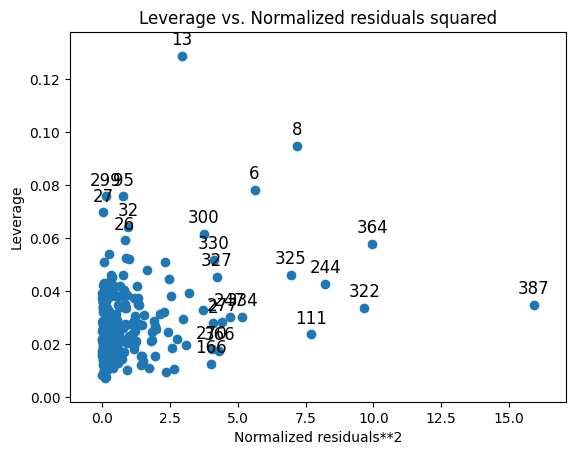

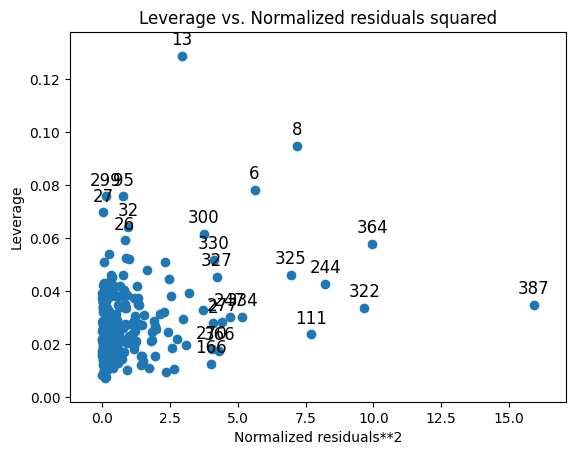

In [44]:
# Leverage plot
from statsmodels.graphics.regressionplots import plot_leverage_resid2
plot_leverage_resid2(Gamma_pca_results)

In [45]:
# Show row values with index number 13
print(X_train_pca.index[13])
print(Gamma_pca_results.predict(X_train_pca))
# Retireve the entry that has name 387
print(X_train_pca.loc[13])

390
61     23.238536
103    12.646458
302    30.814627
338    29.994014
397    29.362060
         ...    
95     10.766547
287    17.491266
316    22.694399
273    28.967677
67     11.302884
Length: 254, dtype: float64
acceleration   -2.035797
model_year     -1.714278
origin                 1
make               buick
PC1             3.737974
PC2             1.884534
Name: 13, dtype: object


In [46]:
# Inverse Gaussian without PCA
IG = smf.glm(formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + model_year + C(origin)",
                 data = pd.concat([X_train, y_train], axis=1),
                 family= sm.families.InverseGaussian(link=sm.families.links.InverseSquared()))
IG_results = IG.fit()
IG_results.summary()
IG_mse = mean_squared_error(IG_results.predict(X_test), y_test)
IG_mae = mean_absolute_error(IG_results.predict(X_test), y_test)
print(f"MSE of {IG_mse}, MAE of {IG_mae}, BIC of {IG_results.bic}")

MSE of 17.771622662291115, MAE of 2.82110951435227, BIC of -1356.4753336924473


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


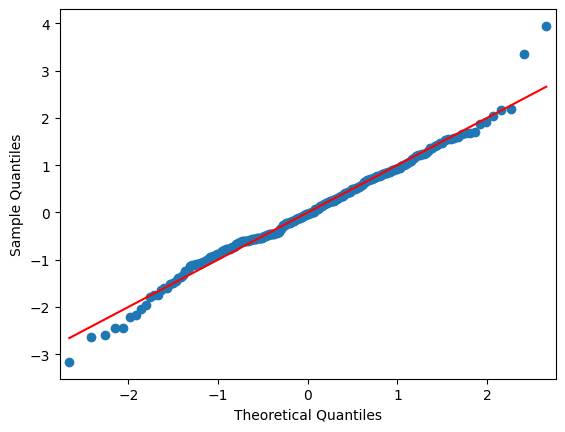

In [47]:
plot = sm.qqplot(
    stats.zscore(IG_results.resid_deviance), line="s")

In [48]:
# Inverse Gaussian PCA GLM
IG_pca = smf.glm(formula = "mpg ~ PC1 + PC2 + acceleration + model_year + C(origin)",
                 data = pd.concat([X_train_pca, y_train], axis=1),
                 family= sm.families.InverseGaussian(link=sm.families.links.InverseSquared()))
IG_pca_results = IG_pca.fit()
IG_pca_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    mpg   No. Observations:                  254
Model:                            GLM   Df Residuals:                      247
Model Family:         InverseGaussian   Df Model:                            6
Link Function:         InverseSquared   Scale:                      0.00074894
Method:                          IRLS   Log-Likelihood:                -618.69
Date:                Fri, 25 Jul 2025   Deviance:                      0.17653
Time:                        14:16:19   Pearson chi2:                    0.185
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9971
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0024   4.59e-05     53.028      0.000       0.002       0.003
C(origin)[T.2]    -0.0001   7.21e-05     -1.517      0.129      -0.000    3.19e-05
C(origin)[T.3] -1.094e-05   7.05e-05     -0.155      0.877      -0.000       0.000
PC1                0.0007   2.75e-05     24.181      0.000       0.001       0.001
PC2                0.0002      0.000      2.133      0.033    1.85e-05       0.000
acceleration    5.814e-05   3.85e-05      1.510      0.131   -1.74e-05       0.000
model_year        -0.0003   3.02e-05    -11.341      0.000      -0.000      -0.000
==================================================================================
"""

In [49]:
IG_PCA_mse = mean_squared_error(IG_pca_results.predict(X_test_pca), y_test)
IG_PCA_mae = mean_absolute_error(IG_pca_results.predict(X_test_pca), y_test)
print(f"MSE of {IG_PCA_mse}, MAE of {IG_PCA_mae}, BIC of {IG_pca_results.bic}")

MSE of 15.948634804638385, MAE of 2.7450815481868176, BIC of -1367.5450323279972


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [50]:
dummies = pd.get_dummies(X_train["origin"])
X_train.drop(["origin","make"], axis=1, inplace=True)

In [51]:
X_train_lgbm = pd.concat([X_train, dummies], axis=1)

In [52]:
# LightGBM
import lightgbm as lgbm

lgbm = lgbm.LGBMRegressor()

lgbm_results = lgbm.fit(X=X_train_lgbm, y=y_train)
lgbm_preds = lgbm_results.predict(pd.concat([X_test.drop(["make", "origin"], axis=1), pd.get_dummies(X_test["origin"])], axis=1))
print(f"MAE: {mean_absolute_error(lgbm_preds, y_test)}, MSE: {mean_squared_error(lgbm_preds, y_test)}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 254, number of used features: 9
[LightGBM] [Info] Start training from score 23.492126
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

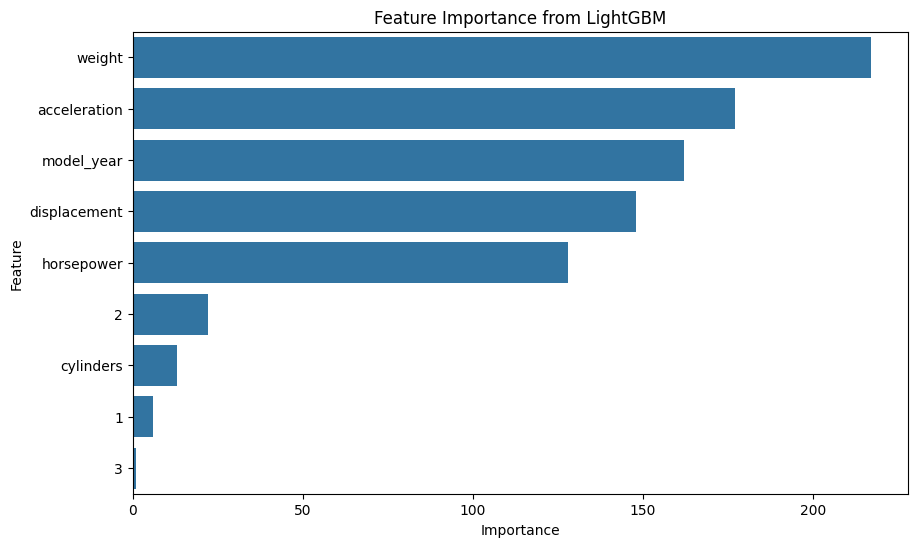

In [53]:
# Feature importance
importances = lgbm_results.feature_importances_
feature_names = X_train_lgbm.columns
# Create a DataFrame for feature importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from LightGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()